In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

# Check if we are currently inside the 'notebooks' folder
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
from src.config import SimConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker, print_markdown_table
from src.utils.plotting import plot_simulation_dashboard, plot_benchmarker_results, plot_markov_matrix 

from src.solvers import HybridSDPSolver, BaselineSDPSolver

from src.controllers import (
    build_approach,
    HybridFCLockedControl,
    HybridPolicyControl,
    HybridValueControl,
    BaselineConstantControl,
    BaselineThresholdControl,
    BaselineSDPControl
)

config = SimConfig()
fleet_data = load_and_cache_entire_fleet(config)

# Initialize benchmarker
exclude_days = [] 
benchmarker = VoyageBenchmarker(fleet_data, config, exclude_days)

Beginning memory staging of all 14 fleet files into RAM...
 -> Day 01 successfully cached in RAM.
 -> Day 02 successfully cached in RAM.
 -> Day 03 successfully cached in RAM.
 -> Day 04 successfully cached in RAM.
 -> Day 05 successfully cached in RAM.
 -> Day 06 successfully cached in RAM.
 -> Day 07 successfully cached in RAM.
 -> Day 08 successfully cached in RAM.
 -> Day 09 successfully cached in RAM.
 -> Day 10 successfully cached in RAM.
 -> Day 11 successfully cached in RAM.
 -> Day 12 successfully cached in RAM.
 -> Day 13 successfully cached in RAM.
 -> Day 14 successfully cached in RAM.

All 14 operational days securely held in RAM. Disk I/O locked.


In [4]:
fc_only_approaches = {
    "MacroConstantControl": build_approach(
        controller_cls=BaselineConstantControl,
        is_macro=True
    ),
    "ConstantControl": build_approach(
        controller_cls=BaselineConstantControl
    ),
    "MacroThresholdControl": build_approach(
        controller_cls=BaselineThresholdControl,
        is_macro=True
    ),
    "ThresholdControl": build_approach(
        controller_cls=BaselineThresholdControl
    ),
    "MacroSDPControl": build_approach(
        controller_cls=BaselineSDPControl,
        solver_cls=BaselineSDPSolver,
        is_macro=True
    ),
    "SDPControl": build_approach(
        controller_cls=BaselineSDPControl,
        solver_cls=BaselineSDPSolver
    ),
}

hybrid_approaches = {
    "MacroFCLocked": build_approach(
        controller_cls=HybridFCLockedControl,
        solver_cls=HybridSDPSolver,
        is_macro=True
    ),
    "FCLocked": build_approach(
        controller_cls=HybridFCLockedControl,
        solver_cls=HybridSDPSolver,
    ),
    "MacroPolicy": build_approach(
        controller_cls=HybridPolicyControl,
        solver_cls=HybridSDPSolver,
        is_macro=True
    ),
    "Policy": build_approach(
        controller_cls=HybridPolicyControl,
        solver_cls=HybridSDPSolver,
    ),
    "MacroValue": build_approach(
        controller_cls=HybridValueControl,
        solver_cls=HybridSDPSolver,
        is_macro=True
    ),
    "Value": build_approach(
        controller_cls=HybridValueControl,
        solver_cls=HybridSDPSolver,
    ),
}

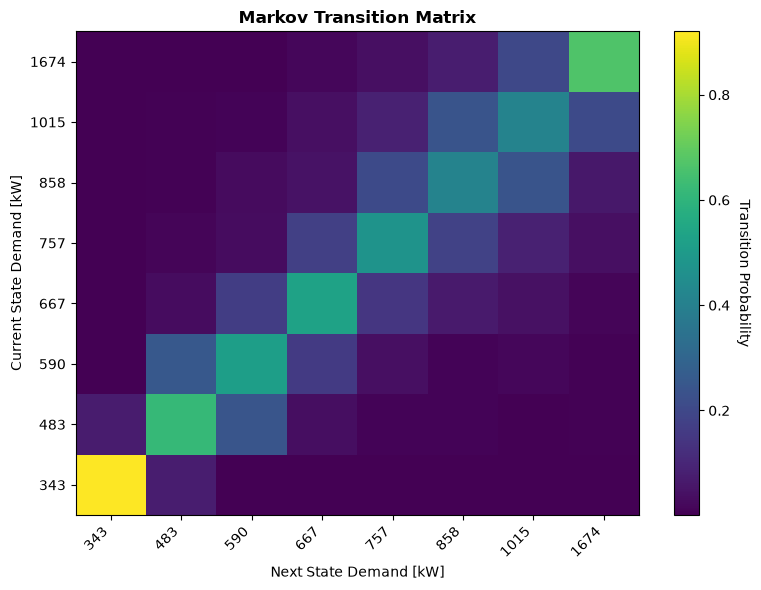

In [5]:
# Manually choose training block and test validation target
train_days = [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
mc_model, _, _ = benchmarker._get_or_compute_models(train_days, solver_cls=None, horizon_length=1)
plot_markov_matrix(mc_model)
test_day = 4
approaches = hybrid_approaches

In [6]:
print("--- APPROACH A: HAND-PICKED EVALUATION ---")

report = benchmarker.compare_approaches(approaches, train_days, test_day)
print_markdown_table(report.summary)

# plot_simulation_dashboard(report.get_telemetry("MacroFCLocked"), benchmarker.config, title="Day 14 - Macro FC Lock", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("FCLocked"), benchmarker.config, title="Day 14 - Micro FC Lock", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("MacroPolicy"), benchmarker.config, title="Day 14 - Macro Policy Matrix", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("Policy"), benchmarker.config, title="Day 14 - Micro Policy Matrix", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("MacroValue"), benchmarker.config, title="Day 14 - Macro Value Function", indiv=False)
plot_simulation_dashboard(report.get_telemetry("Value"), benchmarker.config, title="Day 14 - Micro Value Function", indiv=False)

# plot_simulation_dashboard(report.get_telemetry("MacroConstantControl"), benchmarker.config, title="Day 14 - Macro Constant Control", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("ConstantControl"), benchmarker.config, title="Day 14 - Micro Constant Control", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("MacroThresholdControl"), benchmarker.config, title="Day 14 - Macro Threshold Control", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("ThresholdControl"), benchmarker.config, title="Day 14 - Micro Threshold Control", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("MacroSDPControl"), benchmarker.config, title="Day 14 - Macro SDP Control", indiv=False)
# plot_simulation_dashboard(report.get_telemetry("SDPControl"), benchmarker.config, title="Day 14 - Micro SDP Control", indiv=False)


--- APPROACH A: HAND-PICKED EVALUATION ---
 [Vault] Cache MISS: Solving SDP Bellman matrices (HybridSDPSolver)...


ZeroDivisionError: division by zero

In [ ]:
print("\n--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---")

# Note: Running LOO on all 5 approaches might take a couple of minutes due to 4D solves.
# Let's compare the main engineering deployable hybrid against the legacy baseline.

# for app in approaches:
for app in ["Value"]:
    report = benchmarker.run_leave_one_out(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Leave-One-Out Cross Validation ({app})", plot_type='bar')
    print_markdown_table(report.summary)



In [ ]:
print("\n--- APPROACH C: FORWARD CHAINING (Learning Curve) ---")
# Evaluate how the policy improves as the agent gathers chronological data
# Using the Lookahead Optimum to see the absolute theoretical ceiling of the ship's capabilities

# for app in approaches:
for app in ["Value"]:
    report = benchmarker.run_forward_chaining(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Forward Chaining Learning Curve ({app})", plot_type='line')
    print_markdown_table(report.summary)